# <center style = 'color : white'> Wine Quality </center>

# <center>**Data preprocessing**</center>

# 1. Data Loading and Initial Inspection

In this section we:
- Import the main libraries
- Load the `wine.csv` dataset
- Get a first overview of the data structure



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1.1 Load the dataset
db = pd.read_csv("wine.csv")

In [ ]:
# 1.2 Basic preview
print("Shape of dataset:", db.shape)
display(db.head())      # first rows
display(db.tail())      # last rows

Shape of dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
# 1.3 Data types and non-null counts
print("db.info()")
db.info()

db.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
# 1.4 Basic statistics (numeric columns)
print("db.describe()")
display(db.describe().T)

db.describe()


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [ ]:
# 1.5 Check for missing values
print("Missing values per colum")
display(db.isnull().sum())

Missing values per colum


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# 2. Basic Data Quality Checks

In this section we:
- Verify whether there are duplicated rows in the dataset and remove them if needed.
- Explicitly define the **target variable** (`quality`) and the **feature variables** (all other columns).
- Confirm that all features are numeric and ready for further analysis.

In [ ]:
# 2.1 Check for duplicated rows
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 240


In [ ]:
if num_duplicates > 0:
    db = db.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", db.shape)

Duplicates removed. New shape: (1359, 12)


In [ ]:
num_duplicates = db.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 0


In [ ]:
# 2.2 Identify target and feature columns
target_col = "quality"   # this is our output variable
feature_cols = [col for col in db.columns if col != target_col]

print("\nTarget column:", target_col)
print("Feature columns:", feature_cols)


Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# 3. Visualization – Target Variable (Wine Quality)

In this section we:
- Analyze the distribution of the target variable `quality`, which represents the wine's quality score (from 3 to 8).
- Display the number of samples for each quality level using `value_counts()` to understand class frequencies.
- Create a bar chart to visualize class balance.
- Identify whether the dataset is balanced or imbalanced, which is important for selecting appropriate evaluation metrics in modeling.


## 3.1 Target Variable (Wine Quality)


Value counts for wine quality (sorted):
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


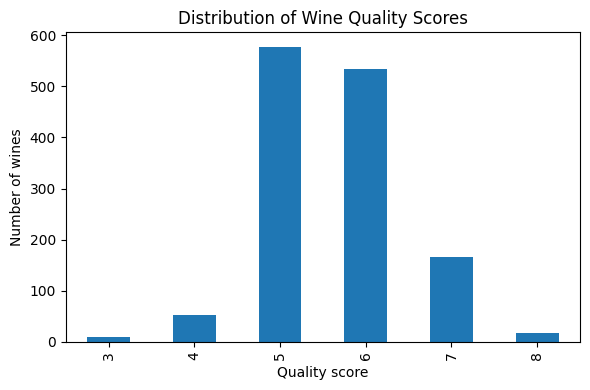

In [ ]:
print("Value counts for wine quality (sorted):")
print(db["quality"].value_counts().sort_index())

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

## 3.2 Visualization – Distributions of Physicochemical Features

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


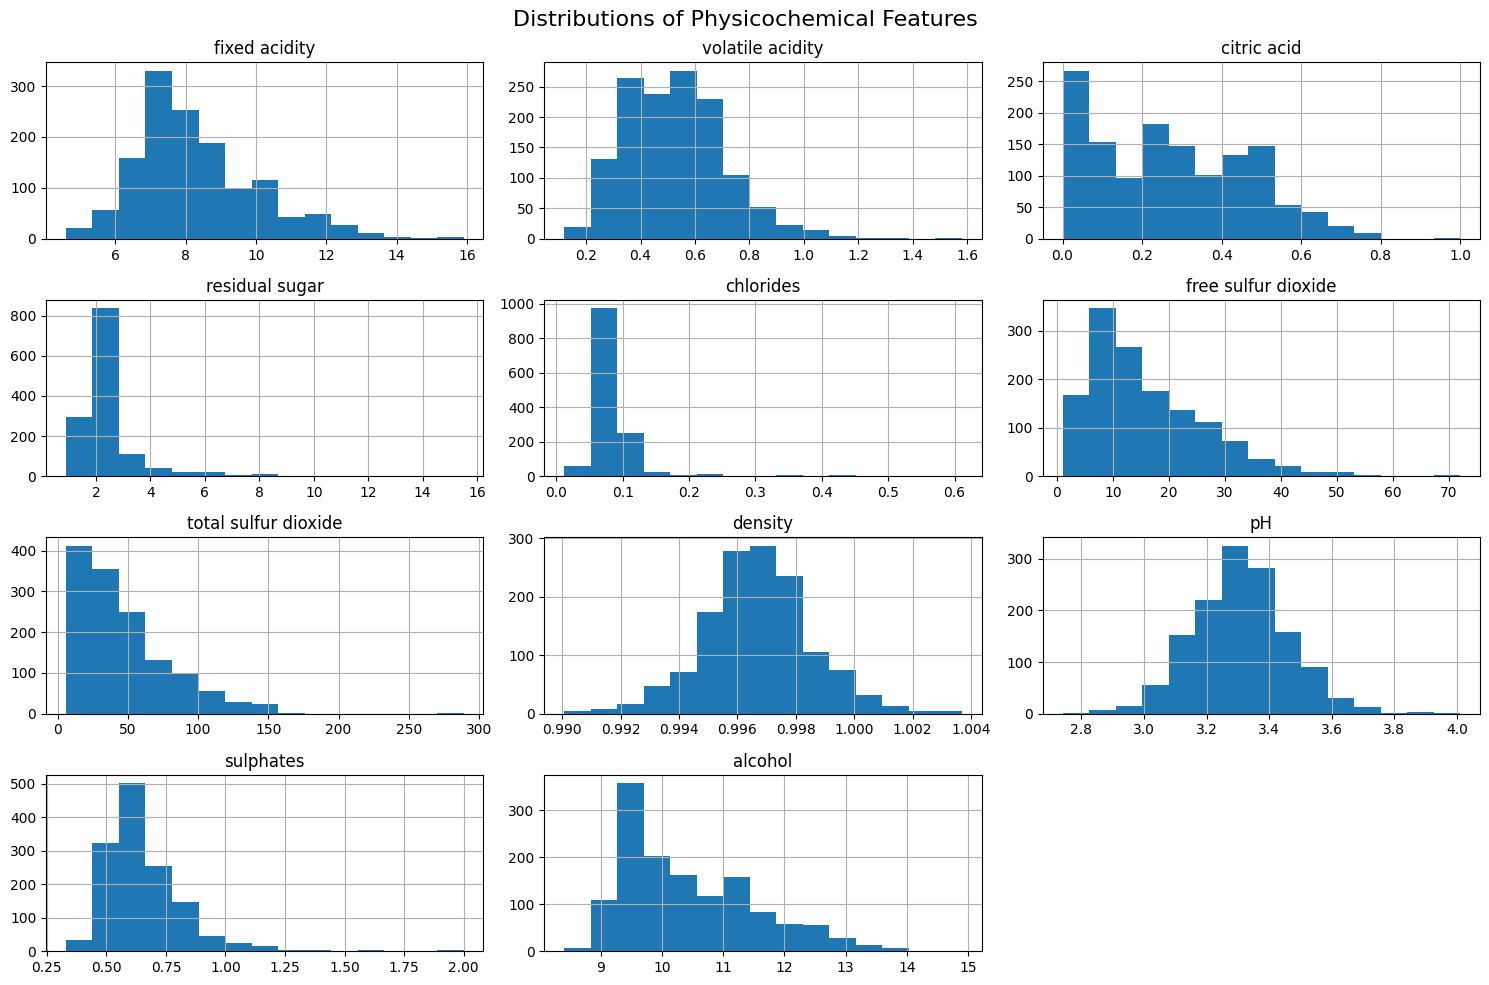

In [ ]:
display(db[feature_cols].describe().T)  # table, not a plot but useful

db[feature_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distributions of Physicochemical Features", fontsize=16)
plt.tight_layout()
plt.show()

## 3.3 Visualization – Relationship Between Features and Quality (Boxplots)

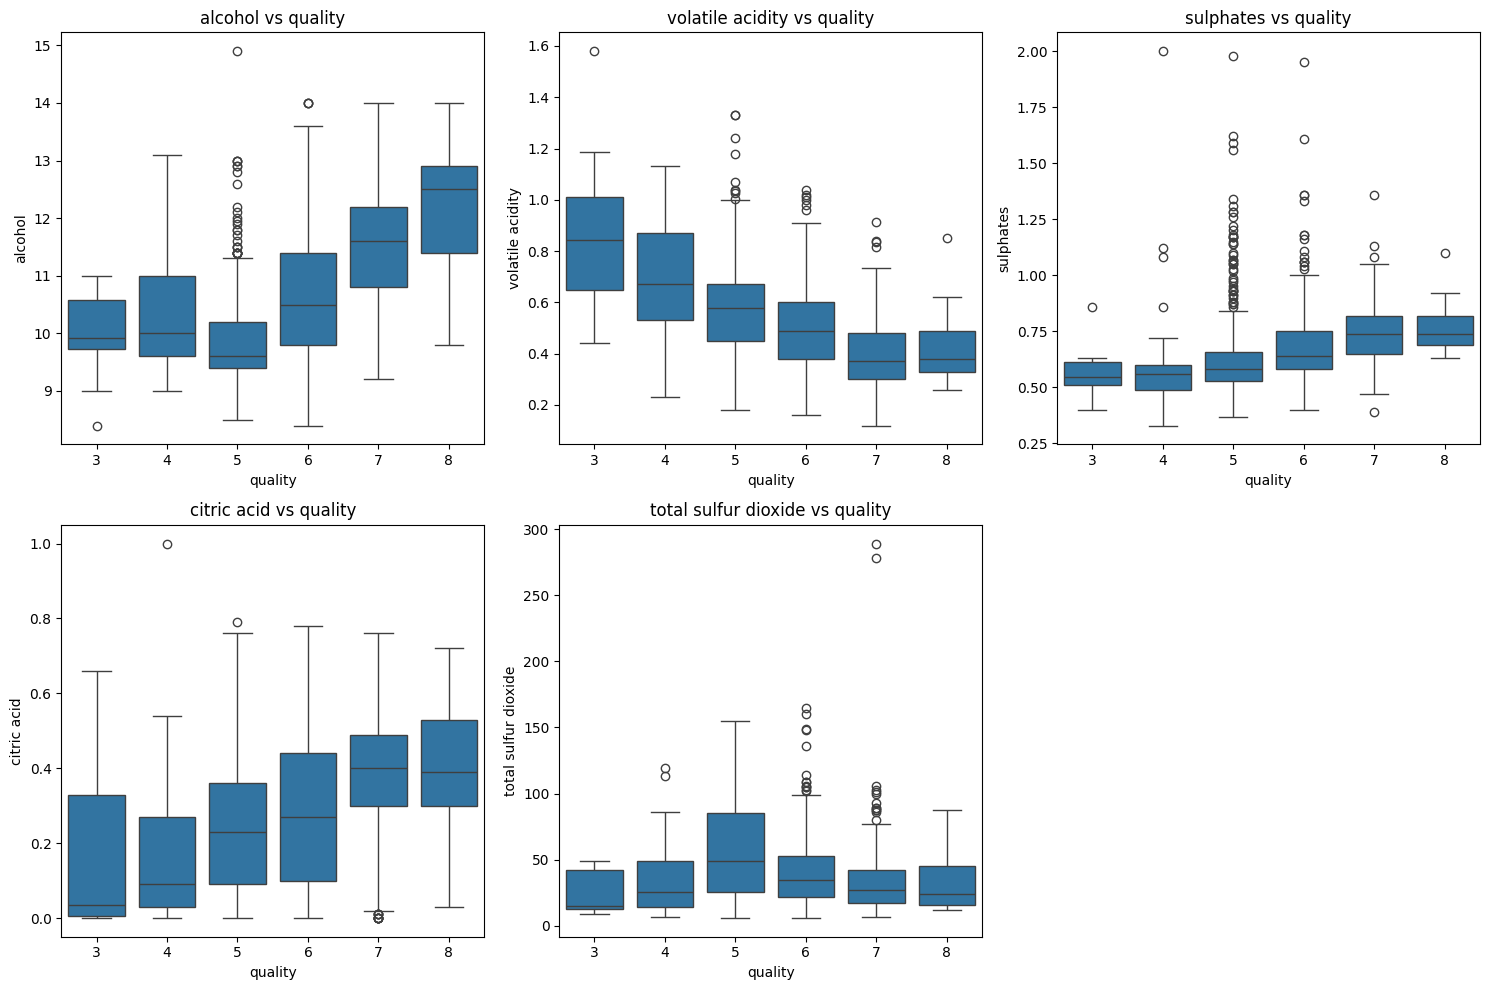

In [ ]:
selected_features = [
    "alcohol",
    "volatile acidity",
    "sulphates",
    "citric acid",
    "total sulfur dioxide"
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=db, x="quality", y=col)
    plt.title(f"{col} vs quality")
    plt.xlabel("quality")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Analysis – Class Balance of Wine Quality

The dataset contains wines with quality scores ranging from **3 to 8**.

From the bar plot and value counts, we observe:

- Quality **5**: 577 samples  
- Quality **6**: 535 samples  
- Quality **7**: 167 samples  
- Quality **4**: 53 samples  
- Quality **8**: 17 samples  
- Quality **3**: 10 samples

This indicates a **moderate class imbalance**:

- The majority of samples fall into **quality 5 and 6**
- Very **few samples** exist for qualities **3, 4, and 8**
- This imbalance must be considered during model evaluation. Metrics like **accuracy** alone may be misleading; it's better to also look at the **confusion matrix**, **precision**, and **recall** for each class.

In conclusion, the dataset is **not fully balanced**, but all classes are still present and we can proceed with multiclass classification.


## 4. Feature Encoding

In this dataset, all variables (input features and the target `quality`) are
numeric. There are no categorical/string features that require encoding
(one-hot or label encoding). Therefore, no encoding step is needed.


# 5. Correlation Analysis – Correlation Matrix and Heatmap

In this section we:
- Compute the correlation matrix between all numerical variables in the dataset.
- Identify how strongly each physicochemical feature is related to the target variable `quality`.
- Visualize the correlations using a heatmap to quickly spot positive and negative relationships.
- Detect highly correlated pairs of input features (multicollinearity), which may affect model performance.
- Interpret which variables show the strongest influence on wine quality (e.g., alcohol, volatile acidity, sulphates).


=== Correlation Matrix ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


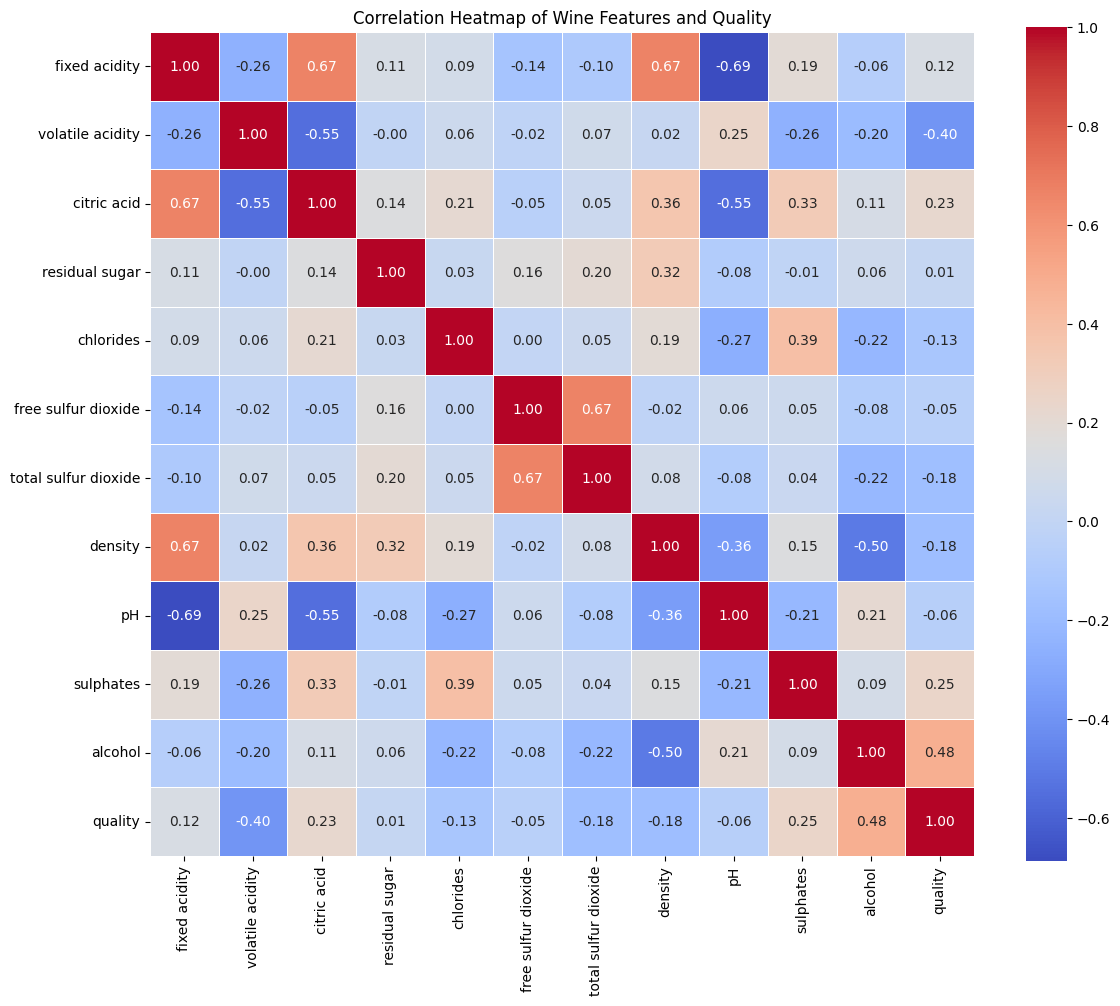


Correlation of each feature with quality:
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


In [ ]:
# 6. Visualization – Correlation Matrix and Heatmap

corr_matrix = db.corr(numeric_only=True)

print("=== Correlation Matrix ===")
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Wine Features and Quality")
plt.tight_layout()
plt.show()

print("\nCorrelation of each feature with quality:")
corr_with_quality = corr_matrix["quality"].sort_values(ascending=False)
print(corr_with_quality)

# 5 Identify target and feature columns


In [ ]:
target_col = "quality"                      # output variable
feature_cols = [c for c in db.columns if c != target_col]

print("Target column:", target_col)
print("Feature columns:", feature_cols)

Target column: quality
Feature columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# 6. Outlier Detection – IQR Method

In this section we:
- Detect potential outliers in each numeric feature using the Interquartile Range (IQR) method.
- Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR = Q3 − Q1 for each variable.
- Define lower and upper bounds as:
  - Lower bound = Q1 − 1.5 × IQR  
  - Upper bound = Q3 + 1.5 × IQR
- Count how many values fall outside these bounds (possible outliers).
- Decide whether to keep or remove these outliers depending on the context (e.g., extreme values in residual sugar or sulfur dioxide that might still represent real wines).


In [ ]:
import pandas as pd

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

rows = []
for col in feature_cols:
    n_out, lb, ub = detect_outliers_iqr(db, col)
    rows.append([col, n_out, lb, ub])

outlier_df = pd.DataFrame(rows, columns=["feature", "n_outliers", "lower_bound", "upper_bound"])
display(outlier_df)

,feature,n_outliers,lower_bound,upper_bound
0,fixed acidity,41,3.95000,12.35000
1,volatile acidity,19,0.01500,1.01500
2,citric acid,1,-0.42000,0.94000
3,residual sugar,126,0.85000,3.65000
4,chlorides,87,0.03850,0.12250
5,free sulfur dioxide,26,-14.00000,42.00000
6,total sulfur dioxide,45,-39.50000,124.50000
7,density,35,0.99227,1.00115
8,pH,28,2.92500,3.68500
9,sulphates,55,0.28000,1.00000


from matplotlib import pyplot as plt
outlier_df['n_outliers'].plot(kind='hist', bins=20, title='n_outliers')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
outlier_df['lower_bound'].plot(kind='hist', bins=20, title='lower_bound')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
outlier_df['upper_bound'].plot(kind='hist', bins=20, title='upper_bound')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
outlier_df.plot(kind='scatter', x='n_outliers', y='lower_bound', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
outlier_df.plot(kind='scatter', x='lower_bound', y='upper_bound', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
outlier_df['n_outliers'].plot(kind='line', figsize=(8, 4), title='n_outliers')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
outlier_df['lower_bound'].plot(kind='line', figsize=(8, 4), title='lower_bound')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
outlier_df['upper_bound'].plot(kind='line', figsize=(8, 4), title='upper_bound')
plt.gca().spines[['top', 'right']].set_visible(False)

##N.B:

### We detect some outliers but we keep them, as they may correspond to real wines.

# 7. Class Balance – Wine Quality

In this section we:
- Examine how the target variable `quality` is distributed across different classes.
- Count the number of wine samples for each quality score using `value_counts()`.
- Visualize the class distribution with a bar plot to better understand any imbalance.
- Identify whether the dataset is balanced or imbalanced, which is critical when choosing appropriate evaluation strategies and metrics.
- Highlight the fact that qualities 5 and 6 dominate the dataset, while extreme values (3, 4, 8) are underrepresented.

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


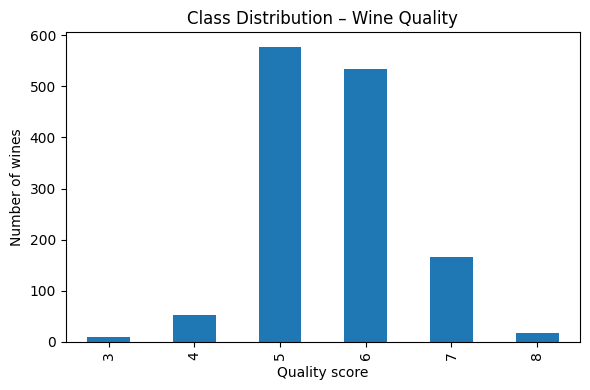

In [ ]:
print(db["quality"].value_counts().sort_index())

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
db["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution – Wine Quality")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.tight_layout()
plt.show()

#N.B:
### Class Balance – Interpretation

The target variable `quality` takes integer values from 3 to 8.  
Most wines are of medium quality (5 and 6), with:

- 577 wines of quality 5  
- 535 wines of quality 6  

Very low (3–4) and very high (7–8) qualities are much less frequent.  
This means the dataset is slightly imbalanced: the models will see many more
examples of “normal” wines than of very bad or excellent wines. We will keep
all classes but interpret the evaluation metrics with this imbalance in mind.

# 8. Preparing Data for Modeling – Train/Test Split and Standardization

In this section we:
- Separate the dataset into:
  - Input features `X` (all columns except `quality`)
  - Target variable `y` (wine quality scores)
- Split the data into **training (80%)** and **test (20%)** sets using stratified sampling to maintain the distribution of quality classes.
- Standardize all input features using `StandardScaler` so that each variable has:
  - Mean = 0  
  - Standard deviation = 1
- Ensure the feature scales are uniform, which is crucial for models that rely on distance (e.g., k-NN, SVM) and neural networks.
- Output `X_train_scaled`, `X_test_scaled`, `y_train`, and `y_test`, which are used in the next phase: model training and evaluation.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 8.1 Separate X and y
X = db[feature_cols]
y = db[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

# 8.2 Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # keeps same quality proportions in train & test
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# 8.3 Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape :", X_test_scaled.shape)

X shape: (1359, 11)
y shape: (1359,)
X_train: (1087, 11)
X_test : (272, 11)

Scaled X_train shape: (1087, 11)
Scaled X_test shape : (272, 11)


### Analyse result: Interpretation of the Train/Test Split and Scaling

After cleaning and exploring the dataset, we prepared the data for modeling:

- The full dataset now contains **1 359 wines** and **11 input features**.
- We split the data into:
  - **Training set:** 1 087 samples (80%)  
  - **Test set:** 272 samples (20%)

The split is **stratified** on the target `quality`, so the distribution of
quality scores (3–8) is similar in both sets. This is important because the
classes are slightly imbalanced.

All 11 features have then been **standardized** using `StandardScaler`, giving:

- `X_train_scaled`: (1 087, 11)  
- `X_test_scaled`: (272, 11)  

Standardization (zero mean, unit variance) puts all physicochemical variables
(acidity, alcohol, sulfur, etc.) on the same scale, which is essential for
many machine learning algorithms and for the neural network we will train.


# <center>**Machine learning models : Imbalanced Data**</center>





# Construction of three ML models

In [ ]:
from sklearn.linear_model import LogisticRegression #importation du modèle de la regression logistique
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#MODEL 1: LOGISTIC REGRESSION
# Simple linear model, fast to train, good baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],           # Regularization strength (inverse)
    'solver': ['lbfgs', 'liblinear']   # Optimization algorithm
}

# MODEL 2: RANDOM FOREST
# Ensemble of decision trees, handles non-linear relationships well
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [10, 20, None],         # Maximum tree depth
    'min_samples_split': [2, 5, 10]      # Min samples to split a node
}

# MODEL 3: GRADIENT BOOSTING
# Builds trees sequentially, each correcting previous errors
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    'n_estimators': [50, 100, 200],      # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],   # Step size shrinkage
    'max_depth': [3, 5, 7]               # Depth of each tree
}

# MODEL 4: SUPPORT VECTOR MACHINE (SVM)
# Finds optimal decision boundaries, good for complex patterns
svm = SVC(random_state=42)
svm_params = {
    'C': [0.1, 1, 10],                   # Regularization parameter
    'kernel': ['rbf', 'linear'],         # Kernel type
    'gamma': ['scale', 'auto']           # Kernel coefficient
}

# Store all models in a dictionary
models = {
    'Logistic Regression': (log_reg, log_reg_params),
    'Random Forest': (rf, rf_params),
    'Gradient Boosting': (gb, gb_params),
    'SVM': (svm, svm_params)
}

print("✓ Models and hyperparameters defined!")

## 1st Three Models : LogisticReg + GaussianNBS + **SVC (Kernel : 'rbf')**

#Training & evaluation of the three Models

In [ ]:
from sklearn.metrics import precision_score, recall_score , accuracy_score, confusion_matrix

def metrics(y_true, y_predict, retur = False):
    pre = precision_score(y_true, y_predict, average = 'macro')
    rec = recall_score(y_true, y_predict, average = 'macro')
    accuracy = accuracy_score(y_true, y_predict)
    if retur :
      return pre, rec, accuracy_score
    else:
      print('precision : ', pre)
      print('recall : ', rec)
      print('accuracy : ', accuracy)

In [ ]:
import joblib

def train_and_evaluate(models, x, y):
    for name, model in models.items():
        print(name, ':')
        model.fit(x, y)
        metrics(y, model.predict(x))
        joblib.dump(model, f'{name}_model.joblib')  # Sauvegarder le modèle avec le nom spécifié
        print(f"Model {name} saved as {name}_model.joblib")
        print("-" * 30)


In [ ]:
print('Three_Models_I')
print(' ')
train_and_evaluate(Three_Models_I,x_train, y_train)

Three_Models_I
 
LogisticRegression :
precision :  0.7186381729725383
recall :  0.6630130929094439
accuracy :  0.76125
Model LogisticRegression saved as LogisticRegression_model.joblib
------------------------------
GaussianNBS :
precision :  0.6998697916666667
recall :  0.7208782067135824
accuracy :  0.74125
Model GaussianNBS saved as GaussianNBS_model.joblib
------------------------------
SVC :
precision :  0.8232554200542005
recall :  0.728852365642167
accuracy :  0.82125
Model SVC saved as SVC_model.joblib
------------------------------


In [ ]:
!pip install statsmodel

ERROR: Could not find a version that satisfies the requirement statsmodel (from versions: none)
ERROR: No matching distribution found for statsmodel
